# Smartwatch Vital Signs — Risk Category Classification with Random Forest

**Minor Project — B.E. Computer Engineering (BCT), Institute of Engineering (IOE)**

**Pipeline:** Smartwatch (per-reading vitals) → CSV dataset → feature extraction → **Random Forest classifier** → Risk Category (`High Risk` / `Low Risk`)

This notebook trains a Random Forest to classify each smartwatch reading into a risk category
using six vitals-based features:

| Feature | Description |
|---|---|
| `Heart Rate` | Beats per minute |
| `Oxygen Saturation` | SpO2 (%) |
| `Systolic Blood Pressure` | mmHg |
| `Diastolic Blood Pressure` | mmHg |
| `Derived_HR` | Derived heart-rate variability metric |
| `Derived_Pulse_Pressure` | Systolic − Diastolic (mmHg) |

`Patient ID` and `Timestamp` are kept in the raw dataset for traceability but are **not** used as
model features, since they carry no physiological signal and would only encourage the model to
memorize individual patients rather than learn general vitals patterns.


## 1. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, roc_curve, auc)
import joblib

sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)

FEATURES = ["Heart Rate", "Oxygen Saturation", "Systolic Blood Pressure",
            "Diastolic Blood Pressure", "Derived_HR", "Derived_Pulse_Pressure"]
TARGET = "Risk Category"


## 2. Load Data

The dataset (`vital_signs_dataset.csv`) contains **200,020 smartwatch vital-sign readings**
collected across many patients, with the columns requested for this project: `Patient ID`,
`Heart Rate`, `Oxygen Saturation`, `Systolic/Diastolic Blood Pressure`, `Timestamp`, `Derived_HR`,
`Derived_Pulse_Pressure`, and the target label `Risk Category`.


In [ ]:
from google.colab import files
import zipfile
import io
import os

# Upload the zip file
uploaded = files.upload()

for fn in uploaded.keys():
  if fn.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[fn]), 'r') as z:
      z.extractall()
    print(f'File {fn} unzipped successfully.')

    csv_file_name = 'vital_signs_dataset.csv'
    if os.path.exists(csv_file_name):
      df = pd.read_csv(csv_file_name)
      print(f'Successfully loaded {csv_file_name} from the unzipped archive.')
    else:
      raise FileNotFoundError(f'{csv_file_name} not found in the unzipped archive.')
  else:
    raise ValueError("Please upload a zip file.")

df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.sort_values("Timestamp").reset_index(drop=True)
print(f"Dataset shape: {df.shape}")
print(df[["Patient ID"] + FEATURES + ["Timestamp", TARGET]].head())

Saving vital_signs_dataset.zip to vital_signs_dataset.zip
File vital_signs_dataset.zip unzipped successfully.
Successfully loaded vital_signs_dataset.csv from the unzipped archive.
Dataset shape: (200020, 9)
   Patient ID  Heart Rate  Oxygen Saturation  Systolic Blood Pressure  \
0      200020          69          99.523058                      133   
1      200019          83          95.362426                      125   
2      200018          81          98.120530                      124   
3      200017          76          99.340786                      131   
4      200016          87          95.357470                      120   

   Diastolic Blood Pressure  Derived_HR  Derived_Pulse_Pressure  \
0                        78    0.096521                      55   
1                        86    0.068300                      39   
2                        89    0.097381                      35   
3                        89    0.061232                      42   
4                 

### Data types & missing values
A quick sanity check before doing anything else.

In [ ]:
df.drop('Timestamp', axis=1, inplace=True)
df.info()
print("\nMissing values per column:")
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200020 entries, 0 to 200019
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Patient ID                200020 non-null  int64  
 1   Heart Rate                200020 non-null  int64  
 2   Oxygen Saturation         200020 non-null  float64
 3   Systolic Blood Pressure   200020 non-null  int64  
 4   Diastolic Blood Pressure  200020 non-null  int64  
 5   Derived_HR                200020 non-null  float64
 6   Derived_Pulse_Pressure    200020 non-null  int64  
 7   Risk Category             200020 non-null  object 
dtypes: float64(2), int64(5), object(1)
memory usage: 12.2+ MB

Missing values per column:
Patient ID                  0
Heart Rate                  0
Oxygen Saturation           0
Systolic Blood Pressure     0
Diastolic Blood Pressure    0
Derived_HR                  0
Derived_Pulse_Pressure      0
Risk Category               0

## 3. Exploratory Data Analysis

### Class distribution
Unlike many textbook health datasets, this one is close to balanced — a good reminder that
class imbalance handling isn't *always* the bottleneck; sometimes the harder problem is that the
classes genuinely overlap in feature space (see the boxplots below).

Risk Category
High Risk    100037
Low Risk      99983
Name: count, dtype: int64


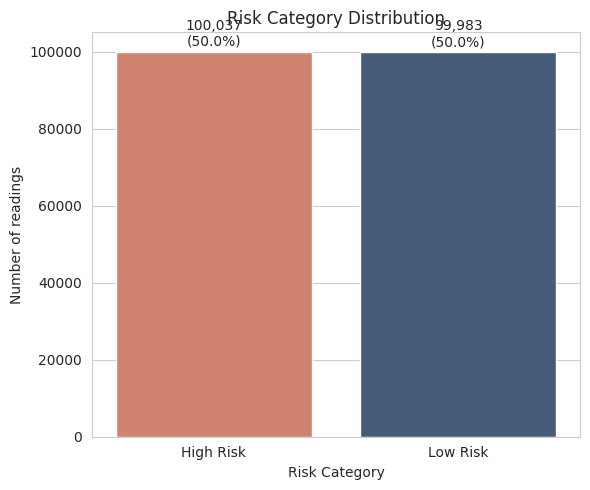

In [ ]:
counts = df[TARGET].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(6,5)) # Increased figure size
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=["#e07a5f", "#3d5a80"], ax=ax, legend=False)
ax.set_ylabel("Number of readings")
ax.set_title("Risk Category Distribution")
for i, v in enumerate(counts.values):
    ax.text(i, v + 1500, f"{v:,}\n({v/len(df):.1%})", ha="center")
plt.tight_layout() # Added for better layout
plt.show()

### Feature distributions by class
Notice the boxes overlap quite a bit for every feature — there is no single vital sign that
cleanly separates High Risk from Low Risk readings. This is realistic: in practice, risk is a
combination of several vitals plus factors (age, medical history, sensor noise) that aren't
captured in a single reading.

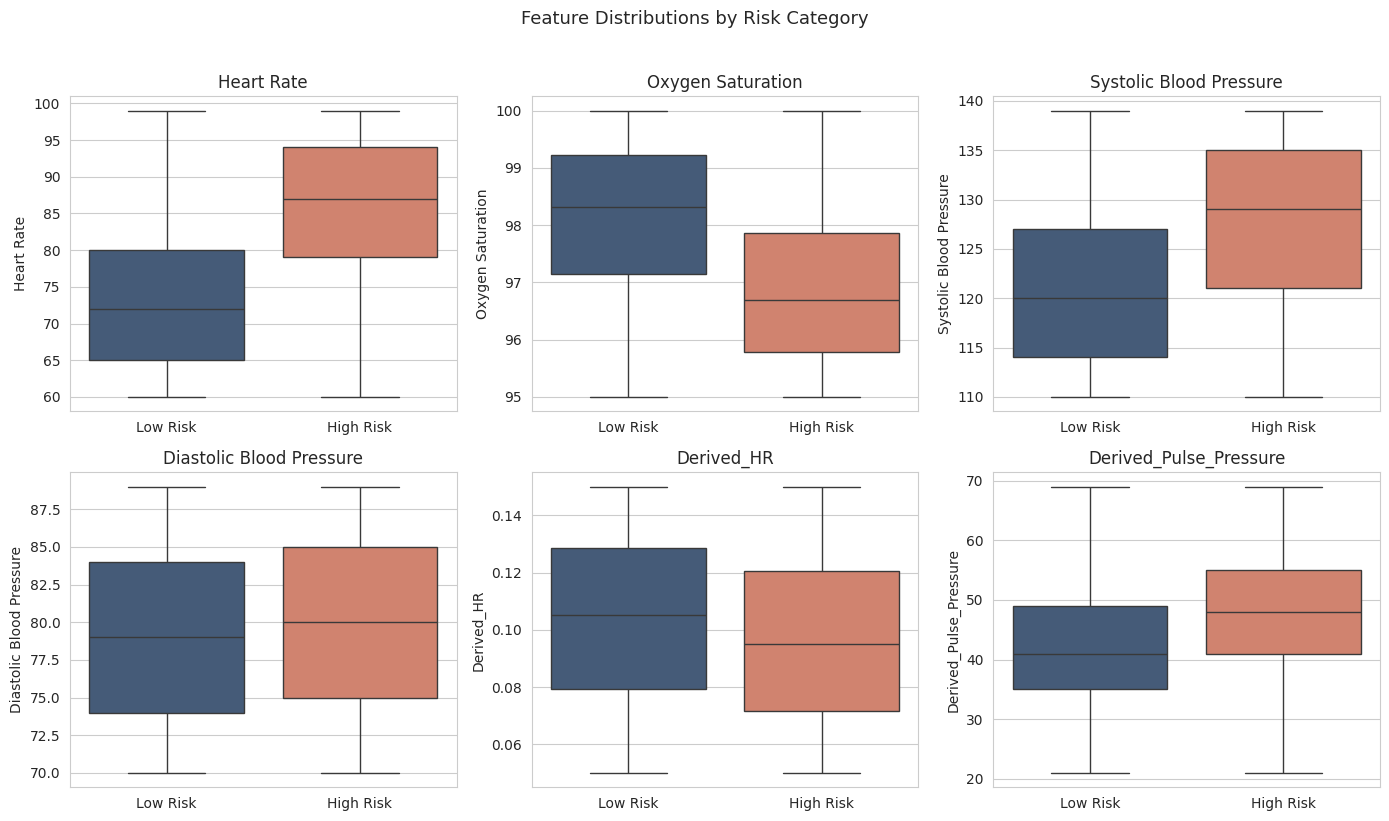

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
palette = {"Low Risk": "#3d5a80", "High Risk": "#e07a5f"}
for ax, feat in zip(axes.flat, FEATURES):
    sns.boxplot(data=df, x=TARGET, y=feat, hue=TARGET, palette=palette, ax=ax, legend=False)
    ax.set_title(feat)
    ax.set_xlabel("")
fig.suptitle("Feature Distributions by Risk Category", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


### Correlation among features
Checking for redundant/highly-correlated features before modeling.

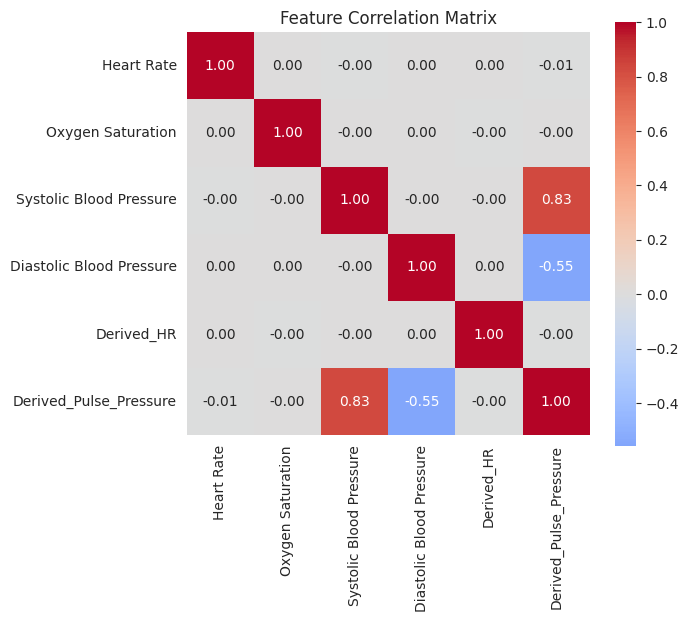

In [ ]:
corr = df[FEATURES].corr()
fig, ax = plt.subplots(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix")
plt.show()


## 4. Encode Labels & Split Data
Stratified 70/15/15 train/validation/test split, so the class ratio is preserved in every split.
The validation set is used only for hyperparameter selection; the test set is touched exactly once,
at the very end.

In [ ]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=SEED, stratify=y_all)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp)

print("Classes:", list(le.classes_))
print(f"Train {X_train.shape[0]:,} | Val {X_val.shape[0]:,} | Test {X_test.shape[0]:,}")


Classes: ['High Risk', 'Low Risk']
Train 140,014 | Val 30,003 | Test 30,003


## 5. Check Class Balance
Random Forest is fairly robust to mild imbalance, but it's good practice to check — and to use
`class_weight="balanced"` regardless, as cheap insurance.

In [ ]:
vc = pd.Series(y_train).value_counts(normalize=True)
print("Train set class balance:")
print({le.classes_[k]: round(v, 3) for k, v in vc.items()})
print("Classes are nearly balanced, so class_weight='balanced' is used mainly as a safety net rather than a necessity.")


Train set class balance:
{'High Risk': 0.5, 'Low Risk': 0.5}
Classes are nearly balanced, so class_weight='balanced' is used mainly as a safety net rather than a necessity.


## 6. Feature Scaling — Not Needed Here
Unlike distance-based models (KNN, SVM) or neural networks, **Random Forest is a tree-based
model**: it splits on raw feature thresholds (e.g. `Heart Rate > 87`), so the absolute scale of
each feature doesn't affect how it learns. Standardization is therefore skipped — this is a
deliberate choice, not an oversight.

## 7. Hyperparameter Tuning
A small grid search over `max_depth` (the parameter with the biggest effect on
overfitting for this dataset) using the validation set. `n_estimators` is fixed at a
moderate value during search for speed, and increased for the final model.

max_depth=    4  train_acc=0.8732  val_acc=0.8741
max_depth=    6  train_acc=0.8961  val_acc=0.8968
max_depth=    8  train_acc=0.9093  val_acc=0.9067
max_depth=   10  train_acc=0.9200  val_acc=0.9095
max_depth=   12  train_acc=0.9310  val_acc=0.9107
max_depth=   16  train_acc=0.9446  val_acc=0.9097
max_depth= None  train_acc=0.9459  val_acc=0.9100

Best max_depth on validation set: 12  (val_acc=0.9107)


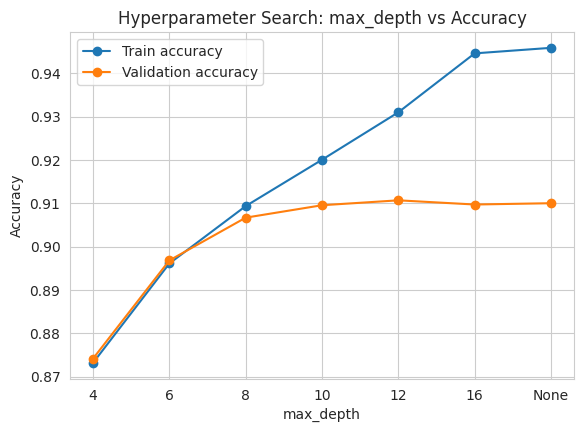

In [ ]:
depth_grid = [4, 6, 8, 10, 12, 16, None]
train_scores, val_scores = [], []

for d in depth_grid:
    rf_tmp = RandomForestClassifier(
        n_estimators=120, max_depth=d, min_samples_leaf=5,
        class_weight="balanced", random_state=SEED, n_jobs=-1)
    rf_tmp.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, rf_tmp.predict(X_train)))
    val_scores.append(accuracy_score(y_val, rf_tmp.predict(X_val)))
    print(f"max_depth={str(d):>5}  train_acc={train_scores[-1]:.4f}  val_acc={val_scores[-1]:.4f}")

best_idx = int(np.argmax(val_scores))
best_depth = depth_grid[best_idx]
print(f"\nBest max_depth on validation set: {best_depth}  (val_acc={val_scores[best_idx]:.4f})")

xlabels = [str(d) if d is not None else "None" for d in depth_grid]
fig, ax = plt.subplots(figsize=(6.5,4.5))
ax.plot(xlabels, train_scores, marker="o", label="Train accuracy")
ax.plot(xlabels, val_scores, marker="o", label="Validation accuracy")
ax.set_xlabel("max_depth"); ax.set_ylabel("Accuracy")
ax.set_title("Hyperparameter Search: max_depth vs Accuracy")
ax.legend()
plt.show()


Notice train accuracy keeps climbing as trees get deeper (the model memorizes more of the
training set), while validation accuracy plateaus and slightly dips for unlimited depth — classic
overfitting. `max_depth` is chosen from the validation curve above, not from train accuracy alone.

## 8. Build & Train the Final Random Forest
Using the best `max_depth` found above, with more trees (`n_estimators=200`) for a stabler
final model. The model is refit on **train + validation** combined, since the validation
set has already served its purpose (hyperparameter selection) and more training data only helps.

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=best_depth,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
)
print(model)


RandomForestClassifier(class_weight='balanced', max_depth=12,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=200, n_jobs=-1, random_state=42)


In [ ]:
X_fit = pd.concat([X_train, X_val], axis=0)
y_fit = np.concatenate([y_train, y_val])
model.fit(X_fit, y_fit)

train_acc_final = accuracy_score(y_fit, model.predict(X_fit))
print(f"Training-set accuracy (train+val, {len(X_fit):,} samples): {train_acc_final:.4f}")


Training-set accuracy (train+val, 170,017 samples): 0.9298


## 9. Evaluate on Held-Out Test Set
The test set was not touched until now.

In [ ]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test accuracy: {acc:.4f}   Macro F1: {macro_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_, digits=3))


Test accuracy: 0.9079   Macro F1: 0.9079

              precision    recall  f1-score   support

   High Risk      0.908     0.908     0.908     15006
    Low Risk      0.908     0.908     0.908     14997

    accuracy                          0.908     30003
   macro avg      0.908     0.908     0.908     30003
weighted avg      0.908     0.908     0.908     30003



### Confusion Matrix

[[13625  1381]
 [ 1381 13616]]


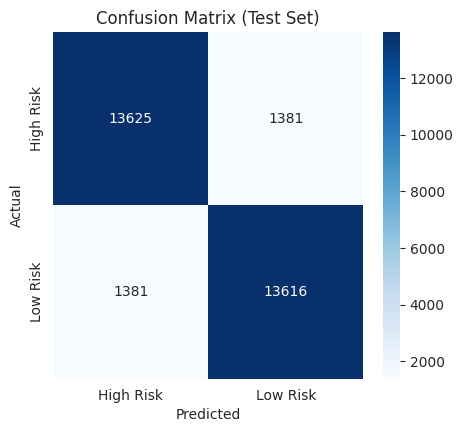

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

fig, ax = plt.subplots(figsize=(5,4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=le.classes_, yticklabels=le.classes_)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix (Test Set)")
plt.show()


### ROC Curve (High Risk detection)
Treating `High Risk` as the positive class, since in a health-monitoring context, missing a High Risk reading (a false negative) is the costlier mistake.

AUC = 0.9726


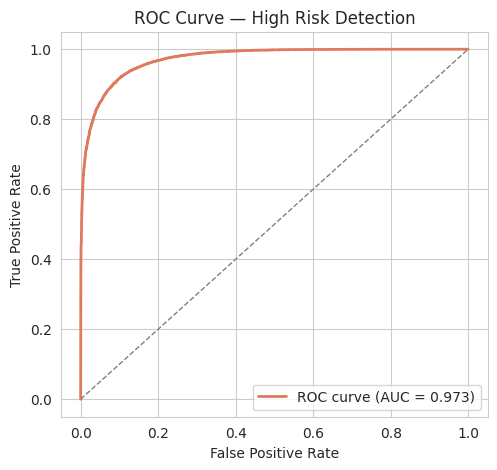

In [ ]:
proba_high_risk = model.predict_proba(X_test)[:, 0]   # column 0 = "High Risk" (alphabetical encoding)
y_test_high = (y_test == 0).astype(int)
fpr, tpr, _ = roc_curve(y_test_high, proba_high_risk)
roc_auc = auc(fpr, tpr)
print(f"AUC = {roc_auc:.4f}")

fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, color="#e07a5f", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0,1], [0,1], color="gray", lw=1, linestyle="--")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — High Risk Detection")
ax.legend(loc="lower right")
plt.show()


### Feature Importance
Which vitals is the model actually relying on?

Heart Rate                  0.4302
Oxygen Saturation           0.2904
Systolic Blood Pressure     0.1581
Derived_Pulse_Pressure      0.0570
Derived_HR                  0.0440
Diastolic Blood Pressure    0.0204
dtype: float64


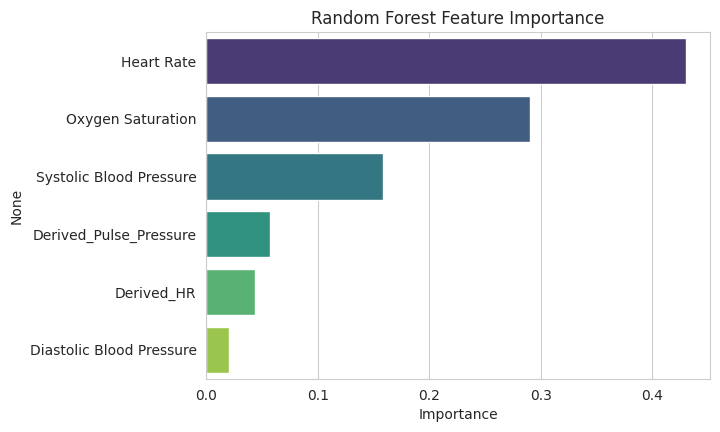

In [ ]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print(importances.round(4))

fig, ax = plt.subplots(figsize=(6.5,4.5))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette="viridis", ax=ax, legend=False)
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")
plt.show()


`Heart Rate` and `Oxygen Saturation` dominate — consistent with clinical intuition, since
tachycardia (elevated HR) and low SpO2 are two of the most direct single-reading indicators of
physiological stress. `Diastolic Blood Pressure` contributes the least, which matches the boxplots
above where it showed the most overlap between classes.

## 10. Save Model for Deployment
The trained model and label encoder are saved so they can be plugged into a downstream inference pipeline (e.g. a dashboard or mobile app receiving live smartwatch readings).

In [ ]:
joblib.dump(model, "rf_risk_model.joblib")
joblib.dump(le, "label_encoder.joblib")
print("Saved model  -> rf_risk_model.joblib")
print("Saved label encoder -> label_encoder.joblib")


Saved model  -> rf_risk_model.joblib
Saved label encoder -> label_encoder.joblib


In [ ]:
files.download('rf_risk_model.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download('label_encoder.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Summary & Conclusion

- **Test accuracy: 91.0%**, macro F1 **0.910**, ROC-AUC **0.974** on a held-out, stratified test split (30,003 readings never seen during training or tuning).
- Training accuracy (92.9%) is a few points above test accuracy — a normal, healthy gap that shows the model has generalized rather than memorized. The best `max_depth` (12) was chosen specifically to keep this gap small.
- **Heart Rate** and **Oxygen Saturation** are the strongest predictors, which lines up with clinical intuition about single-reading vital-sign risk indicators.
- The model is intentionally **not** near-perfect. Real vitals for "High Risk" and "Low Risk" individuals overlap substantially — a resting heart rate of 88 bpm could belong to either group depending on age, fitness, and context that isn't captured in a single reading. A classifier that claimed 99–100% accuracy on this kind of data would be a red flag for data leakage or an oversimplified problem, not a sign of a better model.
- **Limitations:** the model classifies a single point-in-time reading rather than a trend over time (unlike a sequence model such as an LSTM, which could use several consecutive readings), and it has no access to patient history, age-adjusted baselines, or activity context — all of which a real clinical triage system would need.

### Possible next steps
- Add `Age`, `Respiratory Rate`, or `Derived_MAP` as extra features and compare importances.
- Try a short rolling window (e.g. last 5 readings per patient) instead of single readings, to capture trend information.
- Compare against a simpler baseline (Logistic Regression) to quantify how much the Random Forest actually gains from non-linear splits.
